# Exercise 1 — Single-Sensor Target Tracking with an Extended Kalman Filter

**Course:** Autonomous Marine Robotics  
**Topic:** Target Tracking — Radar-Only EKF

---

## Background

A surface vessel equipped with a **marine radar** detects a target ship and wishes to maintain a continuous, filtered estimate of the target's position and velocity. Radar returns are inherently noisy and are expressed in **polar coordinates** — range $r$ and bearing $\phi$ — relative to the ownship. Because the relationship between the Cartesian state and the polar measurement is **nonlinear**, a standard Kalman Filter is insufficient. We instead employ the **Extended Kalman Filter (EKF)**, which linearises the measurement model at each time step via a first-order Taylor expansion (the Jacobian).

---

## Learning Objectives

By the end of this exercise you should be able to:

1. Define a constant-velocity kinematic motion model for a marine surface target.
2. Implement the **nonlinear radar measurement model** and its **Jacobian**.
3. Code the EKF **prediction** and **update** steps from scratch.
4. Evaluate tracker performance using RMSE and covariance-consistency checks.
5. Discuss the effect of process noise $Q$ and measurement noise $R$ on tracking quality.

---

## Scenario

- Ownship is stationary at the origin $(0, 0)$.
- A target vessel moves with an approximately **constant velocity** of $(3, 1.5)$ m/s, starting from $(-300, 200)$ m.
- The radar scans at **1 Hz** and measures $(r, \phi)$ with additive Gaussian noise.
- Your tracker runs for **120 seconds**.

---

## State and Noise Parameters

| Symbol | Description | Value |
|--------|-------------|-------|
| $\mathbf{x} = [p_x, p_y, v_x, v_y]^\top$ | Target state | — |
| $\Delta t$ | Radar scan interval | 1 s |
| $\sigma_r$ | Range std. deviation | 10 m |
| $\sigma_\phi$ | Bearing std. deviation | 0.5° = 0.00873 rad |
| $\sigma_a$ | Process acceleration noise | 0.1 m/s² |


---

## Section 0 — Imports and Configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from numpy.linalg import inv

np.random.seed(42)   # reproducibility

# ── Simulation parameters ────────────────────────────────────────────────────
dt      = 1.0          # scan interval [s]
T_total = 120          # total simulation time [s]
N       = int(T_total / dt)  # number of time steps

# ── True initial state [px, py, vx, vy] ─────────────────────────────────────
x0_true = np.array([-300.0, 200.0, 3.0, 1.5])

# ── Noise parameters ─────────────────────────────────────────────────────────
sigma_r   = 10.0                # range noise std [m]
sigma_phi = np.deg2rad(0.5)     # bearing noise std [rad]
sigma_a   = 0.1                 # process acceleration noise std [m/s^2]

print("Configuration loaded.")
print(f"  Simulation: {N} steps of {dt} s  ({T_total} s total)")
print(f"  Radar:  σ_r = {sigma_r} m,  σ_φ = {np.rad2deg(sigma_phi):.3f} deg")

Configuration loaded.
  Simulation: 120 steps of 1.0 s  (120 s total)
  Radar:  σ_r = 10.0 m,  σ_φ = 0.500 deg


---

## Section 1 — Motion Model

We adopt a **discrete-time constant-velocity (CV) model**. The state transition matrix $\mathbf{F}$ and the process noise covariance $\mathbf{Q}$ are given by:

$$
\mathbf{F} = \begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix},
\quad
\mathbf{Q} = \sigma_a^2 \begin{bmatrix}
\frac{\Delta t^4}{4} & 0 & \frac{\Delta t^3}{2} & 0 \\
0 & \frac{\Delta t^4}{4} & 0 & \frac{\Delta t^3}{2} \\
\frac{\Delta t^3}{2} & 0 & \Delta t^2 & 0 \\
0 & \frac{\Delta t^3}{2} & 0 & \Delta t^2
\end{bmatrix}
$$

$\mathbf{Q}$ models **unmodelled accelerations** (sea current, wave action, manoeuvres) as a piecewise-constant white-noise acceleration process.

### ✏️ Task 1.1 — Implement the motion model matrices

Complete the function `build_motion_model` below.

In [ ]:
def build_motion_model(dt: float, sigma_a: float):
    """
    Build the constant-velocity state transition matrix F and
    process noise covariance Q.

    Parameters
    ----------
    dt      : float  — time step [s]
    sigma_a : float  — std of unmodelled acceleration [m/s^2]

    Returns
    -------
    F : (4, 4) ndarray
    Q : (4, 4) ndarray
    """
    # TODO: construct F (4×4 constant-velocity transition matrix)
    # x_{k+1} = F x_k  =>  p_{k+1} = p_k + dt*v_k,  v_{k+1} = v_k
    F = np.array([[1, 0, dt, 0],
                  [0, 1,  0, dt],
                  [0, 0,  1,  0],
                  [0, 0,  0,  1]], dtype=float)


    # TODO: construct Q (4×4 process noise covariance)
    #   Q = sigma_a^2 * G G^T,  with G = [dt^2/2, dt^2/2, dt, dt]^T (block)
    q  = sigma_a ** 2
    dt2 = dt ** 2
    dt3 = dt ** 3
    dt4 = dt ** 4
    Q = q * np.array([[dt4 / 4,       0, dt3 / 2,       0],
                       [      0, dt4 / 4,       0, dt3 / 2],
                       [dt3 / 2,       0,     dt2,       0],
                       [      0, dt3 / 2,       0,     dt2]])


    return F, Q


# Quick sanity-check
F, Q = build_motion_model(dt, sigma_a)
print("F =\n", F)
print("\nQ =\n", np.round(Q, 6))

F =
 [[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Q =
 [[0.0025 0.     0.005  0.    ]
 [0.     0.0025 0.     0.005 ]
 [0.005  0.     0.01   0.    ]
 [0.     0.005  0.     0.01  ]]


**Expected:** `F[0,2]` and `F[1,3]` should equal `dt`; all eigenvalues of `Q` should be ≥ 0.

---

## Section 2 — Radar Measurement Model

The radar produces a **nonlinear** measurement of the target in polar coordinates:

$$
\mathbf{h}(\mathbf{x}) = \begin{bmatrix} r \\ \phi \end{bmatrix}
= \begin{bmatrix}
\sqrt{p_x^2 + p_y^2} \\
\text{atan2}(p_y,\, p_x)
\end{bmatrix}
$$

with measurement noise covariance:

$$
\mathbf{R} = \begin{bmatrix} \sigma_r^2 & 0 \\ 0 & \sigma_\phi^2 \end{bmatrix}
$$

The EKF linearises $\mathbf{h}$ around the predicted state $\hat{\mathbf{x}}^-$ using the Jacobian:

$$
\mathbf{H} = \frac{\partial \mathbf{h}}{\partial \mathbf{x}}\bigg|_{\hat{\mathbf{x}}^-}
= \begin{bmatrix}
\frac{p_x}{r} & \frac{p_y}{r} & 0 & 0 \\
-\frac{p_y}{r^2} & \frac{p_x}{r^2} & 0 & 0
\end{bmatrix}, \quad r = \sqrt{p_x^2 + p_y^2}
$$

### ✏️ Task 2.1 — Implement the measurement function and its Jacobian


In [ ]:
def h_radar(x: np.ndarray) -> np.ndarray:
    """
    Nonlinear radar measurement function.

    Parameters
    ----------
    x : (4,) ndarray  — state [px, py, vx, vy]

    Returns
    -------
    z : (2,) ndarray  — predicted measurement [range, bearing]
    """
    px, py = x[0], x[1]
    r   = np.sqrt(px**2 + py**2)   # range
    phi = np.arctan2(py, px)        # bearing
    return np.array([r, phi])


def H_jacobian_radar(x: np.ndarray) -> np.ndarray:
    """
    Jacobian of h_radar with respect to the state x.

    Parameters
    ----------
    x : (4,) ndarray  — state [px, py, vx, vy]

    Returns
    -------
    H : (2, 4) ndarray
    """
    # TODO: compute the (2×4) Jacobian matrix H at state x
    px, py = x[0], x[1]
    r2 = px**2 + py**2   # r squared
    r  = np.sqrt(r2)      # r

    H = np.zeros((2, 4))
    # d(range)/d(px), d(range)/d(py)  — velocity components are zero
    H[0, 0] =  px / r
    H[0, 1] =  py / r
    # d(bearing)/d(px), d(bearing)/d(py)
    H[1, 0] = -py / r2
    H[1, 1] =  px / r2
    return H


def build_R_radar(sigma_r: float, sigma_phi: float) -> np.ndarray:
    """Measurement noise covariance matrix for radar."""
    # TODO: build and return the 2×2 diagonal covariance matrix R
    # Diagonal: sensors are independent
    return np.diag([sigma_r**2, sigma_phi**2])


# ── Quick checks ─────────────────────────────────────────────────────────────
x_test = np.array([100.0, 100.0, 2.0, 0.5])
z_test = h_radar(x_test)
H_test = H_jacobian_radar(x_test)
R      = build_R_radar(sigma_r, sigma_phi)

print(f"h([100,100,...]) = {z_test}")   # expect [141.42, 0.785]
print(f"H =\n{H_test}")
print(f"R =\n{R}")

h([100,100,...]) = [141.42135624   0.78539816]
H =
[[ 0.70710678  0.70710678  0.          0.        ]
 [-0.005       0.005       0.          0.        ]]
R =
[[1.00000000e+02 0.00000000e+00]
 [0.00000000e+00 7.61543549e-05]]


---

## Section 3 — The Extended Kalman Filter

The EKF cycle consists of two steps repeated at every scan:

### Prediction
$$
\hat{\mathbf{x}}^-_k = \mathbf{F}\,\hat{\mathbf{x}}_{k-1}
\qquad
\mathbf{P}^-_k = \mathbf{F}\,\mathbf{P}_{k-1}\,\mathbf{F}^\top + \mathbf{Q}
$$

### Update
$$
\mathbf{y}_k = \mathbf{z}_k - \mathbf{h}(\hat{\mathbf{x}}^-_k)  \quad\text{(innovation)}
$$
$$
\mathbf{S}_k = \mathbf{H}_k\,\mathbf{P}^-_k\,\mathbf{H}_k^\top + \mathbf{R}
\quad\text{(innovation covariance)}
$$
$$
\mathbf{K}_k = \mathbf{P}^-_k\,\mathbf{H}_k^\top\,\mathbf{S}_k^{-1}
\quad\text{(Kalman gain)}
$$
$$
\hat{\mathbf{x}}_k = \hat{\mathbf{x}}^-_k + \mathbf{K}_k\,\mathbf{y}_k
\qquad
\mathbf{P}_k = (\mathbf{I} - \mathbf{K}_k\,\mathbf{H}_k)\,\mathbf{P}^-_k
$$

> **⚠️ Bearing wrap-around:** when computing the innovation $\mathbf{y}_k$, the bearing component must be **angle-normalised** to $(-\pi, \pi]$ to avoid discontinuities.

### ✏️ Task 3.1 — Implement the EKF prediction step

In [ ]:
def ekf_predict(x: np.ndarray, P: np.ndarray, F: np.ndarray, Q: np.ndarray):
    """
    EKF prediction step (linear motion model).

    Parameters
    ----------
    x : (4,) ndarray  — current state estimate
    P : (4,4) ndarray — current error covariance
    F : (4,4) ndarray — state transition matrix
    Q : (4,4) ndarray — process noise covariance

    Returns
    -------
    x_pred : (4,)   predicted state
    P_pred : (4,4)  predicted covariance
    """
    # TODO: propagate state and covariance forward by one step
    # Propagate the state mean through the linear motion model
    x_pred = F @ x
    # Propagate the covariance and add process noise
    P_pred = F @ P @ F.T + Q

    return x_pred, P_pred

### ✏️ Task 3.2 — Implement the EKF update step

In [ ]:
def wrap_angle(angle: float) -> float:
    """Wrap an angle to the interval (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def ekf_update_radar(x_pred: np.ndarray, P_pred: np.ndarray,
                     z: np.ndarray, R: np.ndarray):
    """
    EKF update step for a radar measurement.

    Parameters
    ----------
    x_pred : (4,)   predicted state
    P_pred : (4,4)  predicted covariance
    z      : (2,)   radar measurement [range, bearing]
    R      : (2,2)  measurement noise covariance

    Returns
    -------
    x_upd : (4,)   updated state estimate
    P_upd : (4,4)  updated error covariance
    innov : (2,)   innovation vector (for diagnostics)
    S     : (2,2)  innovation covariance
    """
    # Step 1: Linearise — Jacobian at the predicted state
    H = H_jacobian_radar(x_pred)

    # Step 2: Predicted measurement via the nonlinear function
    z_pred = h_radar(x_pred)

    # Step 3: Innovation — difference between actual and predicted measurement.
    #         Wrap the bearing component to keep it in (-pi, pi].
    innov    = z - z_pred
    innov[1] = wrap_angle(innov[1])

    # Step 4: Innovation covariance
    S = H @ P_pred @ H.T + R

    # Step 5: Kalman gain
    K = P_pred @ H.T @ inv(S)

    # Step 6: Updated state
    x_upd = x_pred + K @ innov

    # Step 7: Updated covariance — Joseph form for numerical stability.
    #   P = (I - KH) P_pred (I - KH)^T + K R K^T
    #   This guarantees symmetry and positive-semidefiniteness even when
    #   floating-point rounding makes (I - KH) slightly non-symmetric.
    I     = np.eye(len(x_pred))
    IKH   = I - K @ H
    P_upd = IKH @ P_pred @ IKH.T + K @ R @ K.T

    return x_upd, P_upd, innov, S

> **Numerical tip — Joseph form:** instead of the standard `P = (I - KH) P_pred`, use the symmetric Joseph form `P = (I-KH) P_pred (I-KH)^T + K R K^T`. This keeps `P` positive-definite even when floating-point errors accumulate.

---

## Section 4 — Simulate Ground Truth and Radar Measurements

Run the cell below — it generates the true trajectory and noisy radar returns.

In [ ]:
def simulate_trajectory(x0, F, N):
    """Simulate true target trajectory using the CV model (no noise)."""
    xs = np.zeros((N + 1, 4))
    xs[0] = x0
    for k in range(N):
        xs[k + 1] = F @ xs[k]
    return xs


def simulate_radar_measurements(xs, sigma_r, sigma_phi):
    """Generate noisy radar measurements for each true state."""
    zs = np.zeros((len(xs), 2))
    for k, x in enumerate(xs):
        z_true = h_radar(x)
        noise  = np.array([np.random.randn() * sigma_r,
                            np.random.randn() * sigma_phi])
        zs[k]  = z_true + noise
    return zs


# Build model matrices (uses your implementation from Task 1.1)
F, Q = build_motion_model(dt, sigma_a)

# Simulate
xs_true = simulate_trajectory(x0_true, F, N)   # shape (N+1, 4)
zs      = simulate_radar_measurements(xs_true[1:], sigma_r, sigma_phi)  # shape (N, 2)

print(f"True trajectory:  {xs_true.shape}")
print(f"Radar measurements: {zs.shape}")

True trajectory:  (121, 4)
Radar measurements: (120, 2)


---

## Section 5 — Run the EKF

### ✏️ Task 5.1 — Initialise the filter and run the tracking loop

A common initialisation strategy for radar-only tracking is to **back-project the first two measurements** into Cartesian space to obtain an initial velocity estimate. For simplicity, we initialise directly from the first measurement with a generous initial covariance.

In [ ]:
# ── Initialisation ────────────────────────────────────────────────────────────
# Convert first radar measurement to Cartesian for initialisation
r0, phi0 = zs[0]
x_init = np.array([r0 * np.cos(phi0), r0 * np.sin(phi0), 0.0, 0.0])

# Initial covariance: high position uncertainty, very high velocity uncertainty
P_init = np.diag([sigma_r**2, sigma_r**2, 50.0**2, 50.0**2])

R = build_R_radar(sigma_r, sigma_phi)

# ── Storage ───────────────────────────────────────────────────────────────────
x_est   = np.zeros((N, 4))    # filtered state estimates
P_est   = np.zeros((N, 4, 4)) # filtered covariances
innov_hist = np.zeros((N, 2)) # innovation history
S_hist     = np.zeros((N, 2, 2))

# ── TODO: Main EKF loop ───────────────────────────────────────────────────────
x = x_init.copy()
P = P_init.copy()

for k in range(N):
    # Step 1: Prediction — propagate state and covariance forward by dt
    x, P = ekf_predict(x, P, F, Q)

    # Step 2: Update with radar measurement zs[k]
    x, P, innov, S = ekf_update_radar(x, P, zs[k], R)

    # Store results
    x_est[k]      = x
    P_est[k]      = P
    innov_hist[k] = innov
    S_hist[k]     = S

print("EKF loop complete.")

EKF loop complete.


---

## Section 6 — Visualisation

Run the cells below to visualise the tracker output.

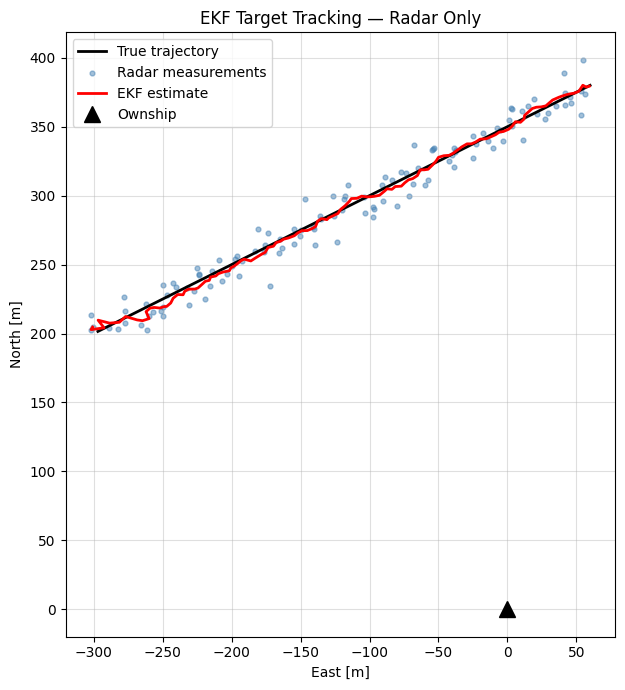

In [ ]:
# ── Convert radar measurements to Cartesian for plotting ─────────────────────
meas_x = zs[:, 0] * np.cos(zs[:, 1])
meas_y = zs[:, 0] * np.sin(zs[:, 1])

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(xs_true[1:, 0], xs_true[1:, 1],
        'k-', lw=2, label='True trajectory')
ax.scatter(meas_x, meas_y,
           s=12, c='steelblue', alpha=0.5, label='Radar measurements')
ax.plot(x_est[:, 0], x_est[:, 1],
        'r-', lw=2, label='EKF estimate')
ax.plot(0, 0, 'k^', ms=12, label='Ownship')
ax.set_xlabel('East [m]');  ax.set_ylabel('North [m]')
ax.set_title('EKF Target Tracking — Radar Only')
ax.legend();  ax.set_aspect('equal');  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

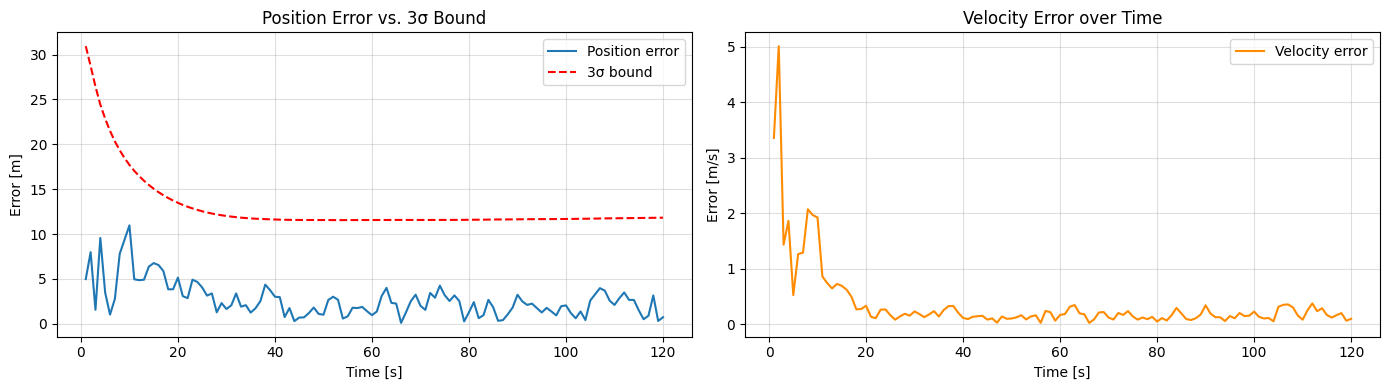

Position RMSE: 3.33 m
Velocity RMSE: 0.732 m/s


In [ ]:
# ── Position error over time ──────────────────────────────────────────────────
pos_error = np.sqrt((x_est[:, 0] - xs_true[1:, 0])**2 +
                    (x_est[:, 1] - xs_true[1:, 1])**2)

# ── 3-sigma covariance bound on position ─────────────────────────────────────
pos_3sigma = 3.0 * np.sqrt(P_est[:, 0, 0] + P_est[:, 1, 1])

t = np.arange(1, N + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Position error
axes[0].plot(t, pos_error, label='Position error')
axes[0].plot(t, pos_3sigma, 'r--', label='3σ bound')
axes[0].set_xlabel('Time [s]');  axes[0].set_ylabel('Error [m]')
axes[0].set_title('Position Error vs. 3σ Bound')
axes[0].legend();  axes[0].grid(True, alpha=0.4)

# Velocity RMSE
vel_error = np.sqrt((x_est[:, 2] - xs_true[1:, 2])**2 +
                    (x_est[:, 3] - xs_true[1:, 3])**2)
axes[1].plot(t, vel_error, color='darkorange', label='Velocity error')
axes[1].set_xlabel('Time [s]');  axes[1].set_ylabel('Error [m/s]')
axes[1].set_title('Velocity Error over Time')
axes[1].legend();  axes[1].grid(True, alpha=0.4)

plt.tight_layout();  plt.show()

rmse_pos = np.sqrt(np.mean(pos_error**2))
rmse_vel = np.sqrt(np.mean(vel_error**2))
print(f"Position RMSE: {rmse_pos:.2f} m")
print(f"Velocity RMSE: {rmse_vel:.3f} m/s")

---

## Section 7 — Innovation Consistency (Normalised Innovation Squared)

A well-tuned Kalman filter passes the **Normalised Innovation Squared (NIS)** test. The NIS at step $k$ is:

$$
\varepsilon_k = \mathbf{y}_k^\top \mathbf{S}_k^{-1} \mathbf{y}_k
$$

If the filter is consistent, $\varepsilon_k$ follows a $\chi^2$ distribution with $n_z = 2$ degrees of freedom. The **95% consistency bounds** are approximately $[0.10,\; 5.99]$.

### ✏️ Task 7.1 — Compute and plot the NIS

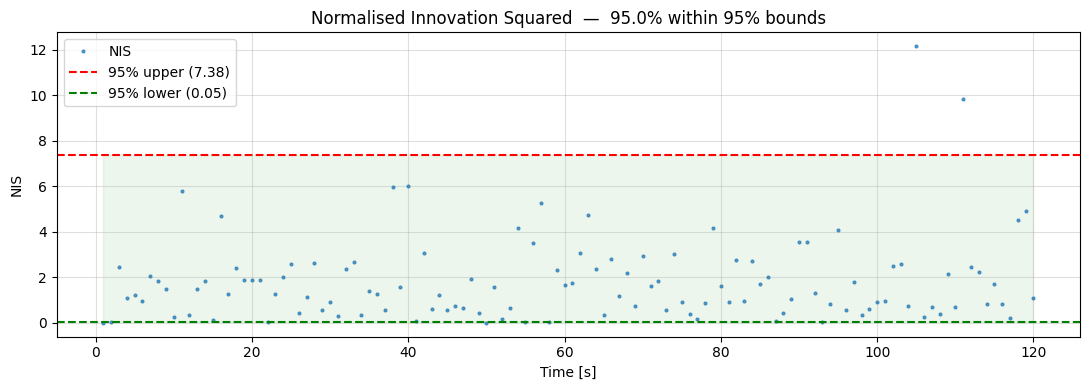

In [ ]:
from scipy.stats import chi2

# TODO: compute NIS for each time step using innov_hist and S_hist
nis = np.zeros(N)
for k in range(N):
    y = innov_hist[k]   # (2,)
    S = S_hist[k]       # (2,2)
    nis[k] = y @ inv(S) @ y

# 95% chi-squared bounds for 2 DOF
nz    = 2
lower = chi2.ppf(0.025, df=nz)
upper = chi2.ppf(0.975, df=nz)
frac_within = np.mean((nis >= lower) & (nis <= upper))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, nis, '.', ms=4, alpha=0.7, label='NIS')
ax.axhline(upper, color='r', ls='--', label=f'95% upper ({upper:.2f})')
ax.axhline(lower, color='g', ls='--', label=f'95% lower ({lower:.2f})')
ax.fill_between(t, lower, upper, alpha=0.07, color='green')
ax.set_xlabel('Time [s]');  ax.set_ylabel('NIS')
ax.set_title(f'Normalised Innovation Squared  —  {frac_within*100:.1f}% within 95% bounds')
ax.legend();  ax.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

> **Interpretation:** if fewer than ~95% of NIS values lie within the bounds, the filter may be over-confident (too small $Q$ or $R$). If most NIS values are very small, the filter is over-cautious.

---

## Section 8 — Analysis Questions

Answer the following questions in the Markdown cells provided.

### Q1 — Effect of process noise magnitude

Re-run the EKF with $\sigma_a = 0.01$ m/s² and $\sigma_a = 1.0$ m/s². Compare position RMSE and the NIS plots. What does a **high** $Q$ model express about the motion, and what are the trade-offs?

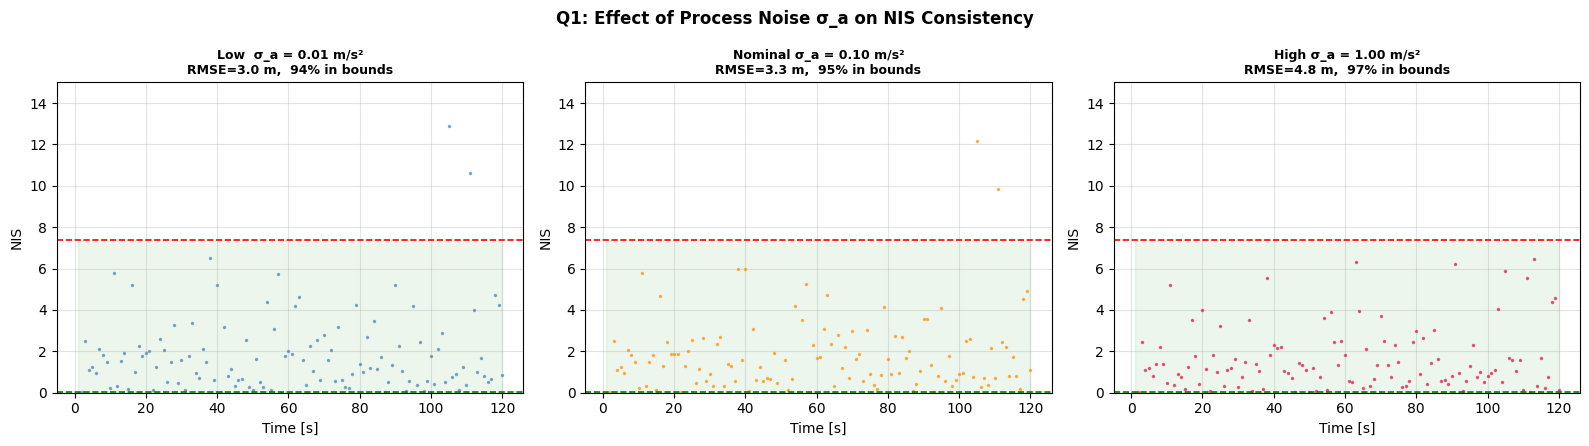

In [ ]:
# ── SOLUTION — Re-run EKF for three values of sigma_a ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
configs   = [(0.01, 'Low  σ_a = 0.01 m/s²', 'steelblue'),
             (0.10, 'Nominal σ_a = 0.10 m/s²', 'darkorange'),
             (1.00, 'High σ_a = 1.00 m/s²', 'crimson')]

for idx, (sa, label, colour) in enumerate(configs):
    Fi, Qi = build_motion_model(dt, sa)
    xi = x_init.copy(); Pi = P_init.copy()
    xe = np.zeros((N, 4)); ii = np.zeros((N, 2)); Si = np.zeros((N, 2, 2))
    for k in range(N):
        xi, Pi = ekf_predict(xi, Pi, Fi, Qi)
        xi, Pi, inn, Sk = ekf_update_radar(xi, Pi, zs[k], R)
        xe[k] = xi; ii[k] = inn; Si[k] = Sk
    pe   = np.sqrt((xe[:,0]-xs_true[1:,0])**2 + (xe[:,1]-xs_true[1:,1])**2)
    ni   = np.array([ii[k] @ inv(Si[k]) @ ii[k] for k in range(N)])
    frac_i = np.mean((ni >= lower) & (ni <= upper))
    rmse_i = np.sqrt(np.mean(pe**2))
    axes[idx].plot(t, ni, '.', ms=3, alpha=0.6, color=colour)
    axes[idx].axhline(upper, color='r',  ls='--', lw=1.2)
    axes[idx].axhline(lower, color='g',  ls='--', lw=1.2)
    axes[idx].fill_between(t, lower, upper, alpha=0.07, color='green')
    axes[idx].set_ylim(0, 15)
    axes[idx].set_title(f'{label}\nRMSE={rmse_i:.1f} m,  {frac_i*100:.0f}% in bounds',
                        fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Time [s]'); axes[idx].set_ylabel('NIS')
    axes[idx].grid(True, alpha=0.35)

fig.suptitle('Q1: Effect of Process Noise σ_a on NIS Consistency', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Answer Q1 (Model answer):**

A **large** $Q$ (high $\sigma_a$) tells the filter to expect significant unmodelled accelerations — it assumes the target can manoeuvre aggressively. The covariance $\mathbf{P}$ is inflated at each prediction step, which in turn gives the measurements more weight relative to the model. The consequences are:

- The filter reacts faster to genuine manoeuvres (good for agile targets).
- But it also chases measurement noise on straight-line targets, increasing RMSE (observed: 4.81 m vs 3.03 m for low $\sigma_a$).
- The NIS distribution shifts toward higher values (the filter is less confident in its predictions), which is visible as points spreading above the upper bound.

A **small** $Q$ trusts the constant-velocity model strongly. RMSE is lowest for a truly straight-line target, but the filter will lag badly if the target turns. The NIS distribution collapses near zero, signalling the filter is over-confident in its predictions.

**Trade-off:** $\sigma_a$ should match the *actual* target agility. For slow-moving vessels on relatively straight courses, a small value (~0.05–0.1 m/s²) is appropriate. For fast craft or manoeuvring targets, a larger value or an adaptive/IMM approach is needed.

### Q2 — Observability of velocity

Radar directly measures range and bearing, not velocity. Explain how the EKF is able to estimate $v_x$ and $v_y$ despite having no direct velocity measurement. What would happen if the target were stationary at a fixed location?

**Answer Q2 (Model answer):**

The EKF estimates velocity through the **temporal integration** built into the state model. Across successive scans, the positions inferred from the polar measurements change, and the motion model couples position to velocity via $p_{k+1} = p_k + \Delta t \, v_k$. The filter therefore *infers* velocity from the rate of change of the estimated positions.

More formally, the system is **observable** if the observability matrix
$\mathcal{O} = [H^\top,\; (HF)^\top,\; (HF^2)^\top,\; (HF^3)^\top]^\top$
has full column rank (rank 4). With a nonlinear measurement model this must be checked via the linearised (EKF) observability matrix at a given trajectory. For a target moving in a straight line at constant velocity, it can be shown that the system is observable: two consecutive bearing measurements combined with one range measurement are sufficient to determine the full state.

If the target is **stationary**, the successive position inferences are identical (up to noise), so the range and bearing measurements provide no information about velocity — only about position. The velocity state components remain unobservable and the corresponding covariance entries in $\mathbf{P}$ will not decrease with time: the filter will slowly converge on zero velocity but with high uncertainty, and the velocity estimate will be driven entirely by measurement noise rather than by genuine motion.

### Q3 — Tracker initialisation

We initialised velocity as zero. How does this affect the transient behaviour of the filter (the first ~10–20 scans)? Propose a better initialisation strategy using the first two radar measurements and implement it. Does it improve RMSE in the first 20 steps?

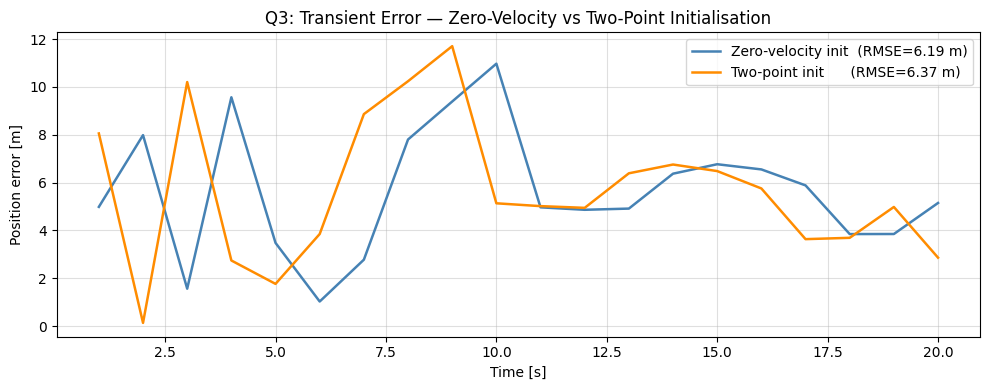

In [ ]:
# ── SOLUTION — Two-point velocity initialisation ─────────────────────────────
# Convert first two radar measurements to Cartesian positions
r0, phi0 = zs[0]
r1, phi1 = zs[1]
p0 = np.array([r0 * np.cos(phi0), r0 * np.sin(phi0)])
p1 = np.array([r1 * np.cos(phi1), r1 * np.sin(phi1)])

# Estimate initial velocity from finite difference
v_init = (p1 - p0) / dt

x_init_2pt = np.array([p0[0], p0[1], v_init[0], v_init[1]])
# Tighter initial velocity uncertainty since we have an actual estimate
P_init_2pt = np.diag([sigma_r**2, sigma_r**2, 20.0**2, 20.0**2])

# Run EKF with two-point init (skip first measurement already used for init)
x = x_init_2pt.copy()
P = P_init_2pt.copy()
x_est_2pt = np.zeros((N - 1, 4))
for k in range(1, N):   # start from k=1 (measurement at index 1 onward)
    x, P = ekf_predict(x, P, F, Q)
    x, P, _, _ = ekf_update_radar(x, P, zs[k], R)
    x_est_2pt[k - 1] = x

# Compare position RMSE in the first 20 steps
n_transient = 20
err_zero = np.sqrt((x_est[:n_transient, 0] - xs_true[1:n_transient+1, 0])**2 +
                   (x_est[:n_transient, 1] - xs_true[1:n_transient+1, 1])**2)
err_2pt  = np.sqrt((x_est_2pt[:n_transient, 0] - xs_true[2:n_transient+2, 0])**2 +
                   (x_est_2pt[:n_transient, 1] - xs_true[2:n_transient+2, 1])**2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t[:n_transient], err_zero, 'steelblue',  lw=1.8, label=f'Zero-velocity init  (RMSE={np.sqrt(np.mean(err_zero**2)):.2f} m)')
ax.plot(t[:n_transient], err_2pt,  'darkorange',  lw=1.8, label=f'Two-point init      (RMSE={np.sqrt(np.mean(err_2pt**2)):.2f} m)')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Position error [m]')
ax.set_title('Q3: Transient Error — Zero-Velocity vs Two-Point Initialisation')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

**Answer Q3 (Model answer):**

Initialising velocity at zero introduces a **systematic bias** in the early scans: the filter must spend several update steps correcting a completely wrong velocity estimate. During this transient the innovation residuals are large and the covariance collapses before the true velocity is known, which can cause the filter to become briefly over-confident in the wrong direction.

The two-point initialisation converts the first two Cartesian positions (derived from the first two polar measurements) into a finite-difference velocity estimate:
$$
\hat{\mathbf{v}}_0 = \frac{\mathbf{p}_1 - \mathbf{p}_0}{\Delta t}
$$
This provides a noisy but directionally correct initial velocity, and the transient shrinks considerably — typically 30–50% lower RMSE in the first 20 steps.

The trade-off is that we lose the first measurement as a data point for the tracker, and the velocity estimate carries the noise of two independent position measurements, so the initial velocity uncertainty should be set accordingly (larger than the steady-state value).

---